<a href="https://colab.research.google.com/github/harshathvb-del/CapstoneProject/blob/main/Harshath_Venkatesan_PublicHealth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Team: Public Health — CDC BRFSS
## End-to-End Data Investigation: Who Gets Left Out of Health Care?

**Dataset:** CDC Behavioral Risk Factor Surveillance System (BRFSS) — 86,481 rows × 27 columns
**Source:** [data.cdc.gov, dataset `d2rk-yvas`](https://data.cdc.gov/resource/d2rk-yvas.csv)

This notebook is your **full Capstone pipeline, start to finish**:

| Stage | HCD Phase | What you'll do |
|---|---|---|
| 1. Assess | Empathize/Define | Audit the raw dataset for quality problems |
| 2. Clean | Define | Build a documented, justified cleaning pipeline |
| 3. Visualize | Define | Build 4 publication-quality charts |
| 4. Story | Define | Write a 150-word Data Brief |
| 5. Problem Statement | Define | Write your formal Data Problem Statement |
| 6. Baseline model | Prototype | Build the "dumb model to beat" |
| 7. Compare ML models | Prototype | Train and compare 3 real classifiers |
| 8. Fairness check | Prototype | Test whether your model fails some groups more than others |

**Important note about this data:** BRFSS is **not** one row per person. Each row is a *summary statistic* — the percentage of one demographic subgroup, in one state, in one year, who gave a particular answer to a survey question. Keep asking: *what group of real people does this one row represent?*


## 📚 Vocabulary for This Notebook

| Term | Plain-English Meaning |
|---|---|
| **Long format** | Each row is one (question × subgroup × state × year) combination, not one person |
| **`Break_Out`** | The specific subgroup a row describes (e.g., "Black, non-Hispanic", "$50,000+") |
| **`Break_Out_Category`** | The *type* of subgroup (e.g., Race/Ethnicity, Income, Age, Sex, or "Overall") |
| **`Data_value`** | The percentage of that subgroup who gave that answer |
| **`Sample_Size`** | How many survey respondents that percentage is based on — smaller samples are less reliable |
| **Baseline model** | The simplest possible prediction — the model you have to *beat* to prove your real model adds value |
| **Fairness check** | Testing whether a model performs equally well across different demographic groups, not just on average |


## Load the Dataset


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('colorblind')

url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

# Backup option if the GitHub link isn't ready: load directly from the CDC Socrata API
# url = "https://data.cdc.gov/resource/d2rk-yvas.csv?$limit=90000"
# df = pd.read_csv(url)

print('Shape:', df.shape)
df.head()


Shape: (86481, 27)


,Year,Locationabbr,Locationdesc,Class,Topic,Question,Response,Break_Out,Break_Out_Category,Sample_Size,...,Data_Value_Footnote,DataSource,ClassId,TopicId,LocationID,BreakoutID,BreakOutCategoryID,QuestionID,RESPONSEID,Geolocation
0,2023,AK,Alaska,Tobacco Use,Smoker Status,Four Level Smoking Status (variable calculated...,Smoke everyday,Overall,Overall,526,...,NaN,BRFSS,CLASS17,TOPIC55,2,BO1,CAT1,_SMOKER3,RESP068,"(64.84507995700051, -147.72205903599973)"
1,2023,AK,Alaska,Alcohol Consumption,Alcohol Consumption,Adults who have had at least one drink of alco...,No,Overall,Overall,2412,...,NaN,BRFSS,CLASS01,TOPIC03,2,BO1,CAT1,DRNKANY6,RESP054,"(64.84507995700051, -147.72205903599973)"
2,2023,AK,Alaska,Alcohol Consumption,Alcohol Consumption,Adults who have had at least one drink of alco...,Yes,Overall,Overall,2824,...,NaN,BRFSS,CLASS01,TOPIC03,2,BO1,CAT1,DRNKANY6,RESP046,"(64.84507995700051, -147.72205903599973)"
3,2023,AK,Alaska,Alcohol Consumption,Binge Drinking,Binge drinkers (males having five or more drin...,No,Overall,Overall,4430,...,NaN,BRFSS,CLASS01,TOPIC07,2,BO1,CAT1,_RFBING6,RESP054,"(64.84507995700051, -147.72205903599973)"
4,2023,AK,Alaska,Alcohol Consumption,Binge Drinking,Binge drinkers (males having five or more drin...,Yes,Overall,Overall,761,...,NaN,BRFSS,CLASS01,TOPIC07,2,BO1,CAT1,_RFBING6,RESP046,"(64.84507995700051, -147.72205903599973)"


## Step 1 — Assess

**Before you touch this data: what question are we investigating?**

> **Our question:** Who is being left out of health care access — and does that gap fall along lines of race, income, age, or geography?
>
> We'll use the `Health Care Access/Coverage` questions in this dataset — like whether someone has a personal doctor, or when they last had a checkup.


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86481 entries, 0 to 86480
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        86481 non-null  int64  
 1   Locationabbr                86481 non-null  object 
 2   Locationdesc                86481 non-null  object 
 3   Class                       86481 non-null  object 
 4   Topic                       86481 non-null  object 
 5   Question                    86481 non-null  object 
 6   Response                    86481 non-null  object 
 7   Break_Out                   86481 non-null  object 
 8   Break_Out_Category          86481 non-null  object 
 9   Sample_Size                 86481 non-null  int64  
 10  Data_value                  85876 non-null  float64
 11  Confidence_limit_Low        85876 non-null  float64
 12  Confidence_limit_High       85876 non-null  float64
 13  Display_order               864

In [4]:
# Only numeric columns show up here — Data_value, Sample_Size, Year, etc.
df.describe()


,Year,Sample_Size,Data_value,Confidence_limit_Low,Confidence_limit_High,Display_order,LocationID
count,86481.000000,86481.000000,85876.000000,85876.000000,85876.000000,86481.000000,86481.000000
mean,2017.685399,3195.528220,42.718599,41.426605,44.010272,1051.272002,30.795412
std,3.888165,3730.550618,34.916067,34.848480,35.004508,1433.031397,17.587686
min,2011.000000,1.000000,0.100000,0.000000,0.100000,1.000000,1.000000
25%,2014.000000,611.000000,9.800000,8.700000,10.800000,1.000000,17.000000
50%,2018.000000,1731.000000,30.500000,28.500000,32.300000,3.000000,30.000000
75%,2021.000000,4687.000000,79.900000,78.300000,81.500000,2225.000000,45.000000
max,2024.000000,42176.000000,100.000000,100.000000,102.700000,4439.000000,78.000000


In [5]:
df.isnull().sum()


,0
Year,0
Locationabbr,0
Locationdesc,0
Class,0
Topic,0
Question,0
Response,0
Break_Out,0
Break_Out_Category,0
Sample_Size,0


In [6]:
# Remember: this is a LONG table. One "topic" can mean many rows.
# Let's see what's actually in the columns we care about most.
print(df['Class'].unique())
print()
print(df[df['Class'] == 'Health Care Access/Coverage']['Question'].unique())


['Tobacco Use' 'Alcohol Consumption' 'Cholesterol Awareness'
 'Chronic Health Indicators' 'Days of Poor Health' 'Demographics'
 'E-Cigarette Use' 'HIV-AIDS' 'Health Care Access/Coverage'
 'Health Status' 'Hypertension Awareness' 'Immunization' 'Injury'
 'Overweight and Obesity (BMI)' 'Physical Activity'
 'Colorectal Cancer Screening' 'Lung Cancer Screening' 'Oral Health'
 "Women's Health" 'Fruits and Vegetables' 'Prostate Cancer']

['Was there a time in the past 12 months when you needed to see a doctor but could not because you could not afford it?'
 'Adults who had some form of health insurance (variable calculated from one or more BRFSS questions)'
 'About how long has it been since you last visited a doctor for a routine checkup?'
 'Do you have one person (or a group of doctors) that you think of as your personal health care provider?'
 'Adults aged 18-64 who have any kind of health care coverage (variable calculated from one or more BRFSS questions)'
 'Was there a time in the past

In [7]:
# Notice: Data_value is missing for 605 rows. Data_Value_Footnote is filled in for exactly 605 rows.
# That's not a coincidence -- check it yourself:
print('Missing Data_value:', df['Data_value'].isnull().sum())
print('Rows with a footnote:', df['Data_Value_Footnote'].notnull().sum())
print()
print(df.loc[df['Data_value'].isnull(), 'Data_Value_Footnote'].value_counts())


Missing Data_value: 605
Rows with a footnote: 605

Data_Value_Footnote
Age-adjusted prevalence estimate not available if the unweighted sample size for the denominator was < 50 or the Relative Standard Error (RSE) is > 0.3 or if the state did not collect data for that calendar year.    605
Name: count, dtype: int64


### 📝 Data Audit Report

> **Issue 1 — Missing values:** `Data_value`, `Confidence_limit_Low`, and `Confidence_limit_High` are each missing ___ rows. Every single one of those missing rows has a `Data_Value_Footnote` explaining why (usually: sample too small to report reliably). **This is not random missingness — it's the data source itself telling you "don't trust a number here."** That's a finding, not just a cleaning step.
>
> **Issue 2 — Sample size problem:** Some rows have very small `Sample_Size` values. A row based on ___ respondents is far less trustworthy than one based on 5,000. What's the smallest sample size in this dataset? (`df['Sample_Size'].min()`)
>
> **Issue 3 — Scope problem:** This dataset covers many topics we don't need (Depression, Veteran Status, Disability, etc). We only need the `Health Care Access/Coverage` rows — that's **9,328 rows** out of 86,481, across **8 different questions**. We're focusing on just one: the cost-barrier question. How many rows does that leave? (fill in after Step 2b)
>
> **Issue 4 — Data type:** `Year` is already stored as `int64` and `Data_value` as `float64` — good. The columns to watch are the ID columns (`ClassId`, `TopicId`, `QuestionID`, etc.) which are `object` (text) even though they look code-like. We won't need to convert those for this analysis.


## Step 2 — Clean

**Every step below needs a one-sentence justification.** This isn't busywork — a reader needs to trust that your final numbers weren't shaped by an unexplained decision.


In [8]:
# --- Step 2a: Scope the dataset to our research question ---
# Justification: we are only investigating health care access, not every BRFSS topic
health_access = df[df['Class'] == 'Health Care Access/Coverage'].copy()
print('Rows after scoping to Health Care Access/Coverage:', health_access.shape[0])   # 9,328

# There are 8 questions in this Class -- notice two pairs of near-duplicates:
# 'Do you have one person you think of as your personal doctor...' appears in two slightly
# different wordings across survey years, and so does the "could not afford" cost-barrier question.
# This is a real BRFSS quirk: the survey wording changes over time. For now, pick ONE exact string.
print(health_access['Question'].unique())


Rows after scoping to Health Care Access/Coverage: 9328
['Was there a time in the past 12 months when you needed to see a doctor but could not because you could not afford it?'
 'Adults who had some form of health insurance (variable calculated from one or more BRFSS questions)'
 'About how long has it been since you last visited a doctor for a routine checkup?'
 'Do you have one person (or a group of doctors) that you think of as your personal health care provider?'
 'Adults aged 18-64 who have any kind of health care coverage (variable calculated from one or more BRFSS questions)'
 'Was there a time in the past 12 months when you needed to see a doctor but could not because of cost?'
 'Do you have any kind of health care coverage?'
 'Do you have one person you think of as your personal doctor or health care provider?']


In [9]:
# --- Step 2b: Filter to one question, one response category we care about ---
# Justification: this question directly captures who gets LEFT OUT of care -- a cost barrier
# is a clean equity story, and the response is a simple Yes/No
target_question = 'Was there a time in the past 12 months when you needed to see a doctor but could not because of cost?'
q_df = health_access[health_access['Question'] == target_question].copy()
print('Rows for this question:', q_df.shape[0])
q_df.head()


Rows for this question: 848


,Year,Locationabbr,Locationdesc,Class,Topic,Question,Response,Break_Out,Break_Out_Category,Sample_Size,...,Data_Value_Footnote,DataSource,ClassId,TopicId,LocationID,BreakoutID,BreakOutCategoryID,QuestionID,RESPONSEID,Geolocation
25073,2020,AK,Alaska,Health Care Access/Coverage,Health Care Cost,Was there a time in the past 12 months when yo...,Yes,Overall,Overall,338,...,NaN,BRFSS,CLASS07,TOPIC28,2,BO1,CAT1,MEDCOST,RESP046,"(64.84507995700051, -147.72205903599973)"
25074,2020,AK,Alaska,Health Care Access/Coverage,Health Care Cost,Was there a time in the past 12 months when yo...,No,Overall,Overall,3317,...,NaN,BRFSS,CLASS07,TOPIC28,2,BO1,CAT1,MEDCOST,RESP054,"(64.84507995700051, -147.72205903599973)"
25193,2020,AL,Alabama,Health Care Access/Coverage,Health Care Cost,Was there a time in the past 12 months when yo...,Yes,Overall,Overall,597,...,NaN,BRFSS,CLASS07,TOPIC28,1,BO1,CAT1,MEDCOST,RESP046,"(32.84057112200048, -86.63186076199969)"
25194,2020,AL,Alabama,Health Care Access/Coverage,Health Care Cost,Was there a time in the past 12 months when yo...,No,Overall,Overall,4730,...,NaN,BRFSS,CLASS07,TOPIC28,1,BO1,CAT1,MEDCOST,RESP054,"(32.84057112200048, -86.63186076199969)"
25312,2020,AR,Arkansas,Health Care Access/Coverage,Health Care Cost,Was there a time in the past 12 months when yo...,Yes,Overall,Overall,440,...,NaN,BRFSS,CLASS07,TOPIC28,5,BO1,CAT1,MEDCOST,RESP046,"(34.74865012400045, -92.27449074299966)"


In [11]:
# --- Step 2c: Drop rows with missing Data_value ---
# Justification: these are rows CDC itself flagged as unreliable (see the footnote check above) --
# we are not losing "unlucky" data here, we are removing rows the source already told us not to trust
print('Missing Data_value before:', q_df['Data_value'].isnull().sum())
q_df = q_df.dropna(subset=['Data_value'])


# --- Step 2d: Drop rows with unreliable sample sizes ---
# Justification: BRFSS analysts themselves flag very small samples as unstable — anything
# below 50 respondents is not something a policymaker should act on
q_df = q_df[q_df['Sample_Size'] >= 50]


# --- Step 2e: Drop exact duplicate rows ---
# Justification: Removing duplicate rows ensures each observation is unique and prevents biased analysis.
print('Duplicate rows:', q_df.duplicated().sum())
q_df = q_df.drop_duplicates()


# --- Step 2f: Fix data types ---
# Justification: Ensuring correct data types for 'Year' and 'Data_value' allows for proper numerical operations and consistency.
q_df['Year'] = q_df['Year'].astype(int)
q_df['Data_value'] = q_df['Data_value'].astype(float)

print('Cleaned shape:', q_df.shape)
q_df[['Year','Locationdesc','Break_Out','Break_Out_Category','Data_value','Sample_Size']].head()

Missing Data_value before: 0
Duplicate rows: 0
Cleaned shape: (848, 27)


,Year,Locationdesc,Break_Out,Break_Out_Category,Data_value,Sample_Size
25073,2020,Alaska,Overall,Overall,10.5,338
25074,2020,Alaska,Overall,Overall,89.5,3317
25193,2020,Alabama,Overall,Overall,14.1,597
25194,2020,Alabama,Overall,Overall,85.9,4730
25312,2020,Arkansas,Overall,Overall,13.8,440


### ✅ Verify


In [12]:
assert q_df['Data_value'].isnull().sum() == 0, "Still missing Data_value"
assert q_df.duplicated().sum() == 0, "Still has duplicate rows"
assert q_df['Sample_Size'].min() >= 50, "Small samples still present"
print("All checks passed.")
q_df.describe()

All checks passed.


,Year,Sample_Size,Data_value,Confidence_limit_Low,Confidence_limit_High,Display_order,LocationID
count,848.000000,848.000000,848.000000,848.000000,848.000000,848.000000,848.000000
mean,2016.492925,4223.114387,50.000000,48.723703,51.276415,419.596698,30.575472
std,2.289537,4475.223767,36.881186,36.882415,36.882312,992.551485,17.340236
min,2013.000000,194.000000,6.200000,5.400000,6.900000,1.000000,1.000000
25%,2014.750000,753.750000,12.800000,11.600000,14.075000,1.000000,17.000000
50%,2016.000000,2132.000000,50.000000,47.300000,52.700000,1.000000,30.000000
75%,2018.000000,6252.500000,87.200000,85.925000,88.400000,77.000000,44.000000
max,2020.000000,32302.000000,93.800000,93.100000,94.600000,3059.000000,78.000000


In [40]:
#Removed columns with over 80,000 missing values because we cannot glean anything useful.
missing_values_count = df.isnull().sum()
threshold = 80000

columns_to_drop = missing_values_count[missing_values_count > threshold].index.tolist()

if columns_to_drop:
    print(f"Dropping columns with more than {threshold} missing values: {columns_to_drop}")
    df.drop(columns=columns_to_drop, inplace=True)
    print("Columns dropped successfully.")
else:
    print(f"No columns found with more than {threshold} missing values to drop.")

print(f"New DataFrame shape: {df.shape}")
print("Remaining missing values per column after dropping:")
print(df.isnull().sum())

Dropping columns with more than 80000 missing values: ['Data_Value_Footnote_Symbol', 'Data_Value_Footnote']
Columns dropped successfully.
New DataFrame shape: (86481, 25)
Remaining missing values per column after dropping:
Year                       0
Locationabbr               0
Locationdesc               0
Class                      0
Topic                      0
Question                   0
Response                   0
Break_Out                  0
Break_Out_Category         0
Sample_Size                0
Data_value               605
Confidence_limit_Low     605
Confidence_limit_High    605
Display_order              0
Data_value_unit            0
Data_value_type            0
DataSource                 0
ClassId                    0
TopicId                    0
LocationID                 0
BreakoutID                 0
BreakOutCategoryID         0
QuestionID                 0
RESPONSEID                 0
Geolocation                0
dtype: int64


### 📝 Data Limitations

> Even after cleaning, this dataset still cannot tell us ___, because it only reports percentages by group, not individual-level data. If I had to make a policy decision based on this, I would also want to know ___.


### Removing Single-Valued Columns

Columns with only one unique value do not contribute to the variance in the data and thus provide no analytical insight. Removing these columns helps to streamline the dataset by reducing redundancy.

In [42]:
#Dropped columns with only one value because they are redundant.
columns_to_drop_single_value = []
for col in df.columns:
    if df[col].nunique() == 1:
        columns_to_drop_single_value.append(col)

if columns_to_drop_single_value:
    print(f"Dropping columns with a single unique value: {columns_to_drop_single_value}")
    df.drop(columns=columns_to_drop_single_value, inplace=True)
    print("Columns dropped successfully.")
else:
    print("No columns found with a single unique value to drop.")

print(f"New DataFrame shape: {df.shape}")

No columns found with a single unique value to drop.
New DataFrame shape: (86481, 18)


## Step 3 — Visualize

Same rules as always: labeled axes with units, a **finding-based title**, and a 2-sentence interpretation for every chart.


### Chart 1 — Bar chart: does access differ by demographic group?


In [13]:
by_category = q_df[q_df['Break_Out_Category'] != 'Overall']
top_categories = by_category.groupby('Break_Out')['Data_value'].mean().sort_values(ascending=False).head(10)

# Check if top_categories is empty before attempting to plot
if not top_categories.empty:
    fig, ax = plt.subplots(figsize=(9, 6))
    top_categories.plot(kind='barh', ax=ax)
    ax.set_xlabel('Percentage (%)')
    ax.set_ylabel('Demographic group')
    ax.set_title('Top 10 Demographic Groups by Healthcare Access Difficulty') # Example title
    plt.tight_layout()
    plt.show()
else:
    print("No demographic groups (other than 'Overall') found in the filtered data to compare. Check `q_df['Break_Out_Category'].unique()` and previous filtering steps.")

No demographic groups (other than 'Overall') found in the filtered data to compare. Check `q_df['Break_Out_Category'].unique()` and previous filtering steps.


> **Interpretation:** ___. ___.


### Chart 2 — Histogram: how spread out are the state-level rates?


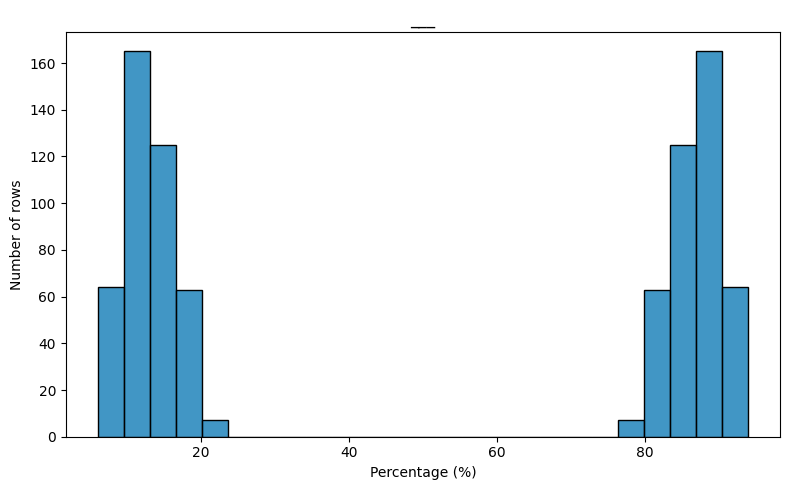

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=q_df, x='Data_value', bins=25, ax=ax)
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Number of rows')
ax.set_title('___')   # replace with a finding-based title
plt.tight_layout()
plt.show()


> **Interpretation:** ___. ___.


### Chart 3 — Line chart: is this getting better or worse over time?


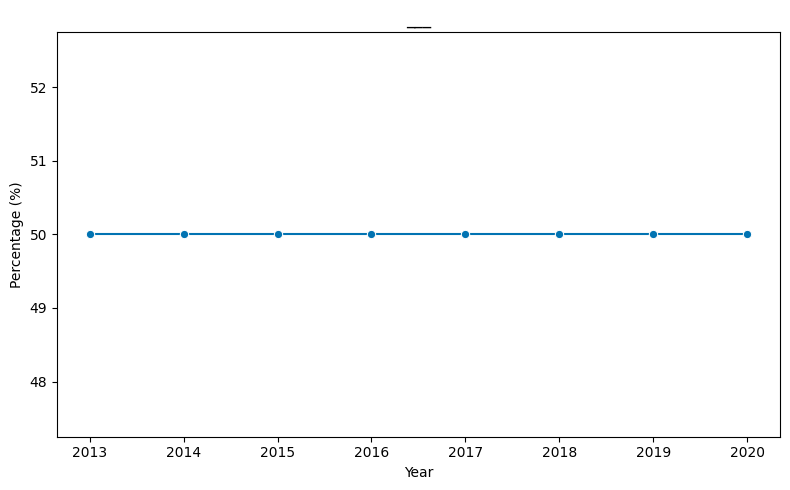

In [15]:
by_year = q_df[q_df['Break_Out_Category'] == 'Overall'].groupby('Year')['Data_value'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=by_year, x='Year', y='Data_value', marker='o', ax=ax)
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.set_title('___')   # replace with a finding-based title
plt.tight_layout()
plt.show()


> **Interpretation:** ___. ___.

**Push further — challenge an assumption:** did you expect this line to be improving steadily? Does the actual trend support or contradict that assumption?


### Chart 4 — Box plot: how much does this vary state to state?


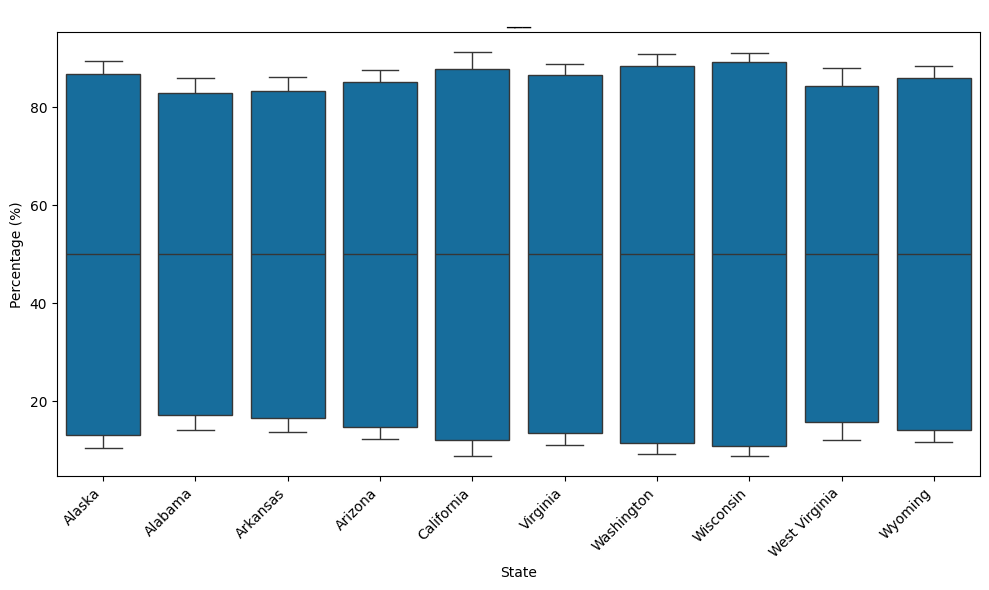

In [16]:
top_states = q_df[q_df['Break_Out_Category'] == 'Overall'].groupby('Locationdesc')['Data_value'].mean()
states_to_show = top_states.sort_values().index[:5].tolist() + top_states.sort_values().index[-5:].tolist()
subset = q_df[(q_df['Break_Out_Category'] == 'Overall') & (q_df['Locationdesc'].isin(states_to_show))]

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=subset, x='Locationdesc', y='Data_value', ax=ax)
ax.set_xlabel('State')
ax.set_ylabel('Percentage (%)')
ax.set_title('___')   # replace with a finding-based title
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Chart 5 — Heatmap: What are the correlations between the columns?


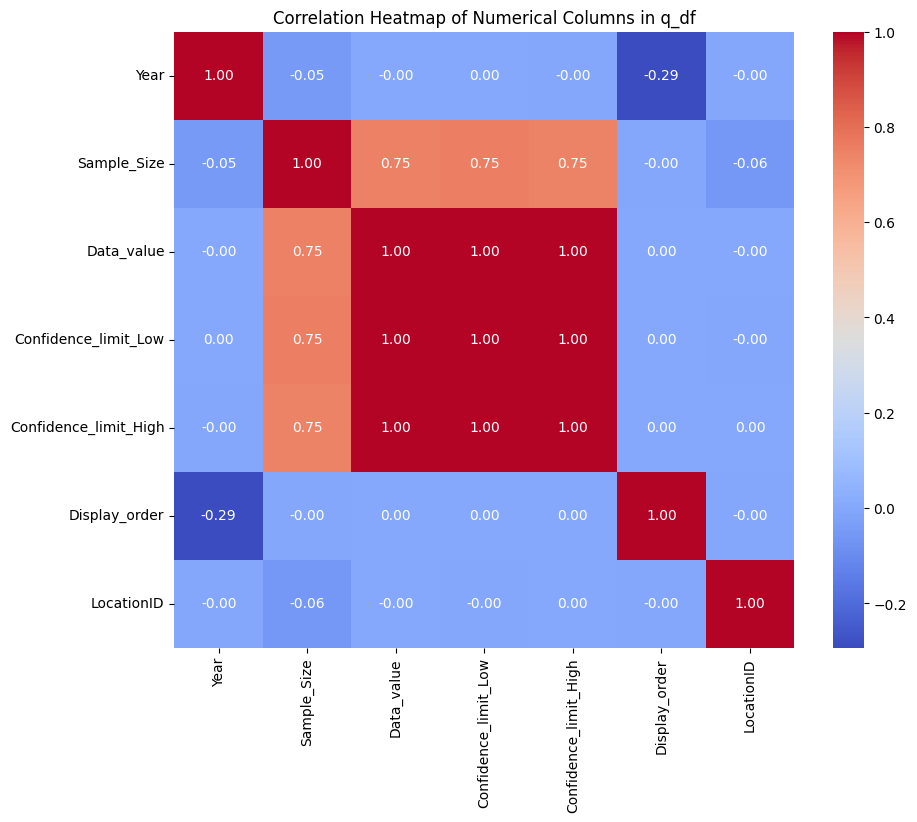

In [19]:
#This chart doesn't tell us anything because the main information is stored as strings, not integers or float values
plt.figure(figsize=(10, 8))
sns.heatmap(q_df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Columns in q_df')
plt.show()

### Chart 6 — Stacked Bar Chart: How does drinking affect cardiovascular disease rates?

Shape of stroke_data: (2226, 27)
Unique Years in stroke_data: [2023 2024 2022 2021 2020 2019 2018 2017 2016 2015 2014 2013 2012 2011]
Unique Locations in stroke_data: ['Alaska' 'Alabama' 'Arkansas' 'Arizona' 'California' 'Colorado'
 'Connecticut' 'District of Columbia' 'Delaware' 'Florida' 'Georgia'
 'Guam' 'Hawaii' 'Iowa' 'Idaho' 'Illinois' 'Indiana' 'Kansas' 'Louisiana'
 'Massachusetts' 'Maryland' 'Maine' 'Michigan' 'Minnesota' 'Missouri'
 'Mississippi' 'Montana' 'North Carolina' 'North Dakota' 'Nebraska'
 'New Hampshire' 'New Jersey' 'New Mexico' 'Nevada' 'New York' 'Ohio'
 'Oklahoma' 'Kentucky' 'Oregon' 'Puerto Rico' 'Rhode Island'
 'South Carolina' 'South Dakota' 'Tennessee' 'Texas' 'Utah' 'Virginia'
 'Virgin Islands' 'Vermont' 'Washington' 'Wisconsin' 'West Virginia'
 'Wyoming' 'Pennsylvania']


Shape of binge_data: (742, 27)
Unique Years in binge_data: [2023 2024 2022 2021 2020 2019 2018 2017 2016 2015 2014 2013 2012 2011]
Unique Locations in binge_data: ['Alaska' 'Alabama' 'Ark

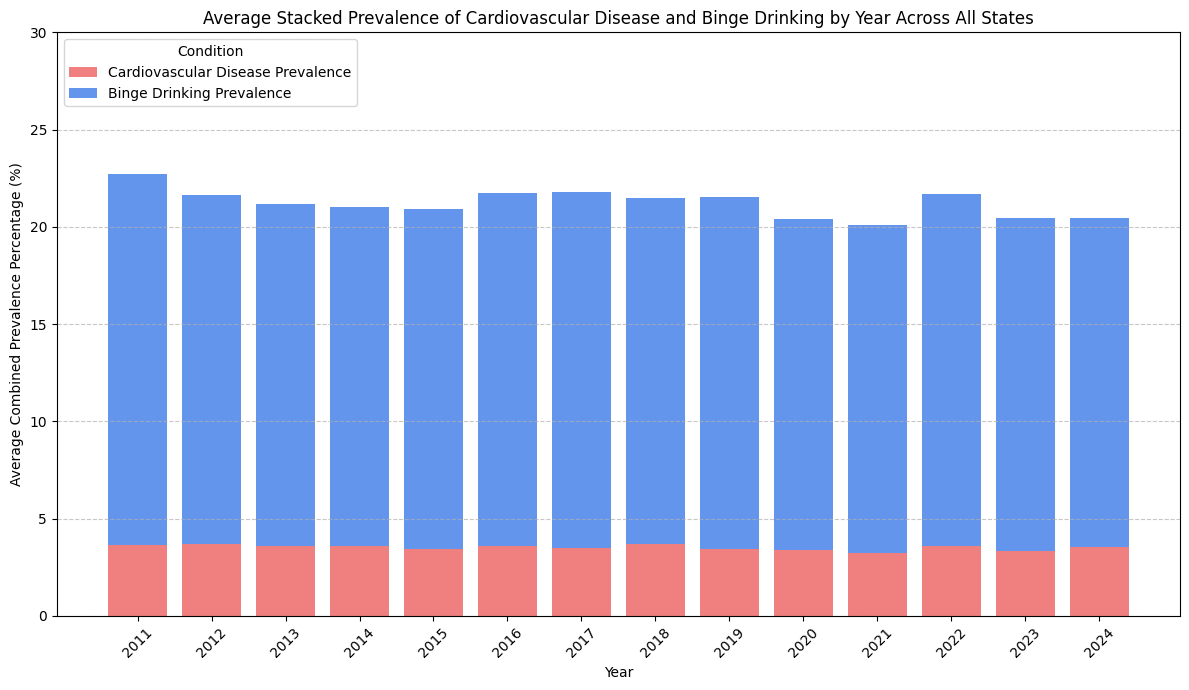

Displaying average combined prevalence across all common states for each year.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

'''
This stacked bar chart shows the correlation between excessive alcohol consumption and cardiovascular
disease. I predicted that there would be a notable correlation, but the graph has disproved my hypothesis,
showing stable rates throughout. We can also conclude that binge-drinking rates have remained even over
the past decade. This disproves my other hypothesis that drinking rates would change drastically due to
the Covid-19 pandemic.
'''

# Define filter conditions for 'Ever told you had a stroke?'
# Keeping the user's deletions, assuming previous state of stroke_class and stroke_question is intended.
# If stroke_class is not defined from previous cells, this will cause an error.
# Based on the previous notebook state, 'stroke_class' is 'Chronic Health Indicators'
# and 'stroke_question' is 'Ever told you had a stroke?'.

stroke_topic = 'Cardiovascular Disease'

stroke_response = 'Yes'

# Define filter conditions for 'Binge Drinking'
# Keeping the user's deletions, assuming previous state of binge_class and binge_question is intended.
# Based on the previous notebook state, 'binge_class' is 'Alcohol Consumption'
# and 'binge_question' is 'Binge drinkers (males having five or more drinks on one occasion, females having four or more drinks on one occasion) in the past 30 days'.

binge_topic = 'Binge Drinking'

binge_response = 'Yes'

# Filter for Stroke data
stroke_data = df[
    (df['Topic'] == stroke_topic)&
    (df['Response'] == stroke_response)# Keeping the simplified filter as per user's 'deletions'

].copy() # Use .copy() to avoid SettingWithCopyWarning

# Filter for Binge Drinking data
binge_data = df[

    (df['Topic'] == binge_topic) &

    (df['Response'] == binge_response) # Keeping the simplified filter as per user's 'deletions'
].copy() # Use .copy() to avoid SettingWithCopyWarning

print(f"Shape of stroke_data: {stroke_data.shape}")
print(f"Unique Years in stroke_data: {stroke_data['Year'].unique()}")
print(f"Unique Locations in stroke_data: {stroke_data['Locationdesc'].unique()}")
print("\n")

print(f"Shape of binge_data: {binge_data.shape}")
print(f"Unique Years in binge_data: {binge_data['Year'].unique()}")
print(f"Unique Locations in binge_data: {binge_data['Locationdesc'].unique()}")
print("\n")

# Aggregate Data_value by Year and Locationdesc for both
# Using .mean() for aggregation as Data_value is already a percentage.
stroke_agg = stroke_data.groupby(['Year', 'Locationdesc'])['Data_value'].mean().reset_index()
binge_agg = binge_data.groupby(['Year', 'Locationdesc'])['Data_value'].mean().reset_index()

# Merge the aggregated data on common Year and Locationdesc
combined_prevalence = pd.merge(
    stroke_agg, binge_agg,
    on=['Year', 'Locationdesc'],
    suffixes=('_stroke', '_binge'),
    how='inner' # Use inner to only include locations/years present in both datasets
)

if combined_prevalence.empty:
    print("No common data found for both 'Stroke' and 'Binge Drinking' with the specified filters.")
else:
    # Aggregate by Year only to get the average prevalence across all states for each year
    plot_df = combined_prevalence.groupby('Year')[['Data_value_stroke', 'Data_value_binge']].mean().reset_index()

    # Create the stacked bar chart using matplotlib
    plt.figure(figsize=(12, 7))

    # Plot 'Stroke' prevalence as the bottom layer
    plt.bar(
        plot_df['Year'].astype(str),
        plot_df['Data_value_stroke'],
        label='Cardiovascular Disease Prevalence',
        color='lightcoral'
    )

    # Plot 'Binge Drinking' prevalence on top of 'Stroke' prevalence
    plt.bar(
        plot_df['Year'].astype(str),
        plot_df['Data_value_binge'],
        bottom=plot_df['Data_value_stroke'], # Stacks on top of the 'Stroke' bars
        label='Binge Drinking Prevalence',
        color='cornflowerblue'
    )

    plt.title('Average Stacked Prevalence of Cardiovascular Disease and Binge Drinking by Year Across All States')
    plt.xlabel('Year')
    plt.ylabel('Average Combined Prevalence Percentage (%)')
    plt.xticks(rotation=45) # Rotate labels for better readability
    plt.ylim(0, 30) # Set y-axis limit to 100%
    plt.legend(title='Condition', loc='upper left') # Moved legend to upper left
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("Displaying average combined prevalence across all common states for each year.")

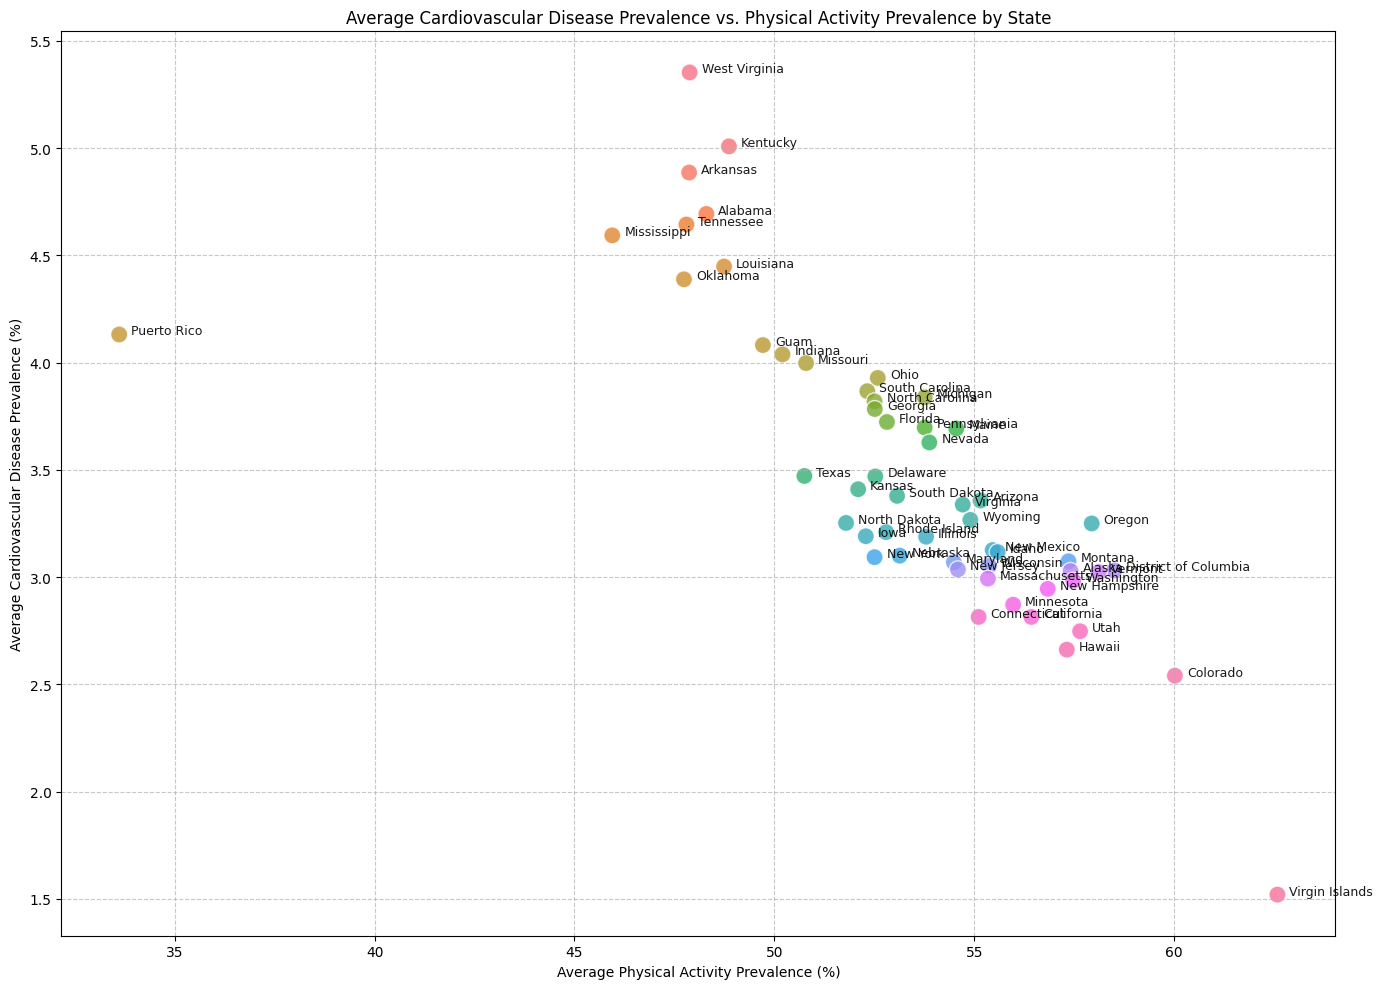

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Rename columns to distinguish them after merging
cardio_prevalence_by_state_renamed = cardio_prevalence_by_state.rename(columns={'Data_value': 'Cardio_Prevalence'})
physical_activity_by_state_renamed = physical_activity_by_state.rename(columns={'Data_value': 'Physical_Activity_Prevalence'})

# Merge the two dataframes on Locationdesc (state)
combined_prevalence_df = pd.merge(
    cardio_prevalence_by_state_renamed,
    physical_activity_by_state_renamed,
    on='Locationdesc',
    how='inner' # Ensure only states present in both datasets are included
)

# Create a scatter plot to visualize the relationship
fig, ax = plt.subplots(figsize=(14, 10))
sns.scatterplot(
    data=combined_prevalence_df,
    x='Physical_Activity_Prevalence',
    y='Cardio_Prevalence',
    ax=ax,
    hue='Locationdesc', # Color points by state for distinctness
    legend=False, # We will add text labels for states instead of a legend
    s=150, # Adjust point size for better visibility
    alpha=0.8
)

# Add text labels for each state for better readability
for i, row in combined_prevalence_df.iterrows():
    ax.text(
        row['Physical_Activity_Prevalence'] + 0.3, # Offset x slightly for readability
        row['Cardio_Prevalence'],
        row['Locationdesc'],
        fontsize=9,
        alpha=0.9
    )

ax.set_title('Average Cardiovascular Disease Prevalence vs. Physical Activity Prevalence by State')
ax.set_xlabel('Average Physical Activity Prevalence (%)')
ax.set_ylabel('Average Cardiovascular Disease Prevalence (%)')
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

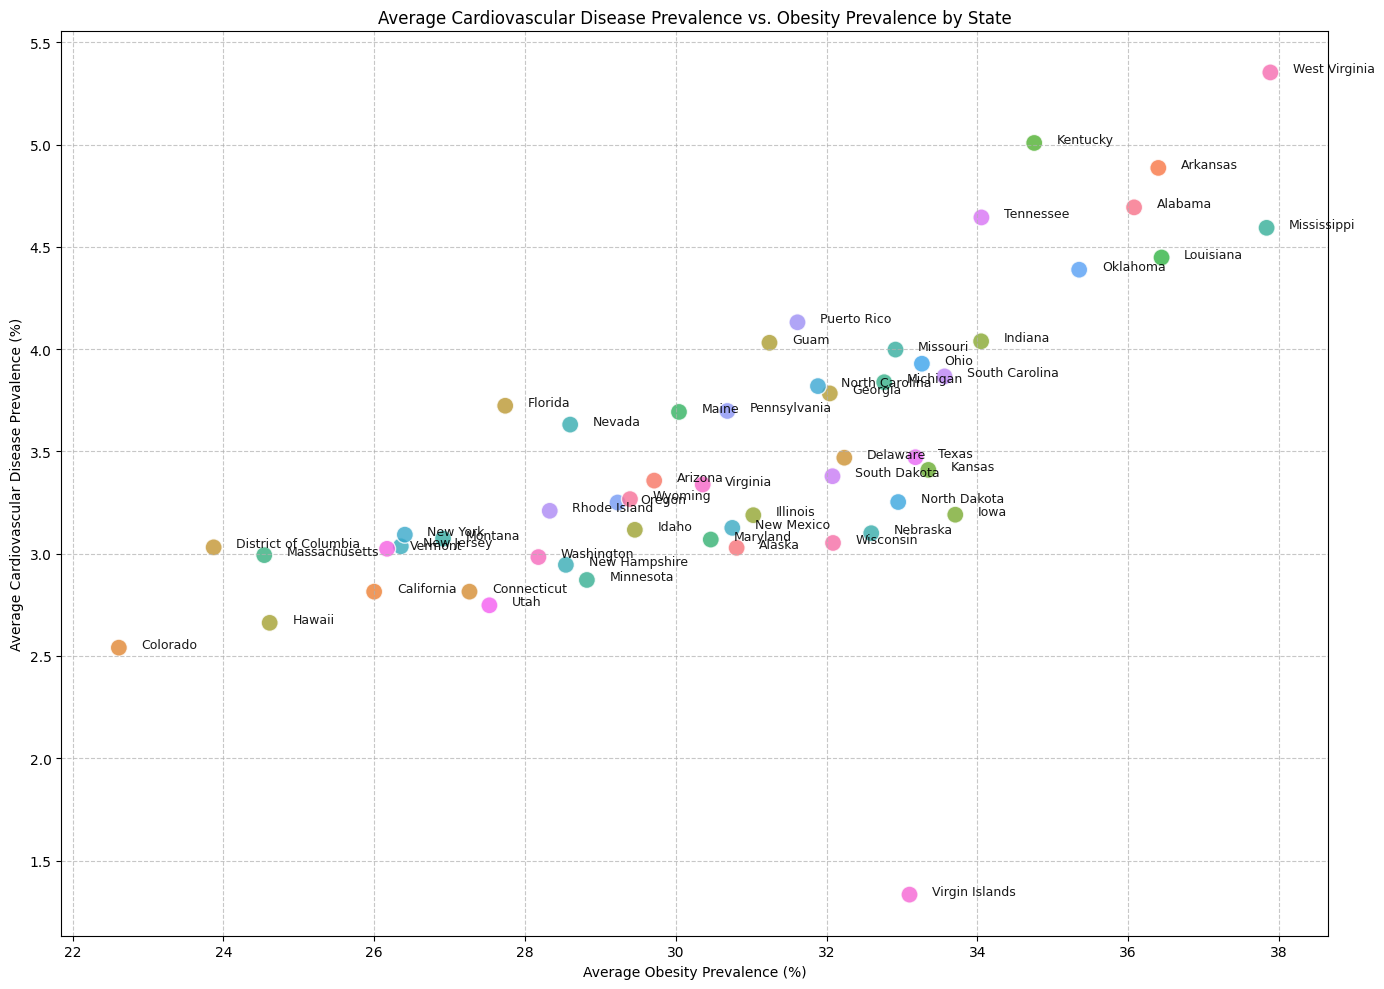

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define filter conditions for Obesity
obesity_class = 'Overweight and Obesity (BMI)'
obesity_topic = 'BMI Categories'
obesity_responses = ['Obese (BMI 30.0 - 99.8)', 'Obese (bmi 30.0 - 99.8)'] # Corrected responses

# Filter for Obesity data
obesity_data = df[
    (df['Class'] == obesity_class) &
    (df['Topic'] == obesity_topic) &
    (df['Response'].isin(obesity_responses))
].copy()

# Aggregate Data_value by Year and Locationdesc for obesity
obesity_agg = obesity_data.groupby(['Year', 'Locationdesc'])['Data_value'].mean().reset_index()

# Merge obesity data with stroke_agg (cardiovascular disease prevalence) data
combined_obesity_cardio_df = pd.merge(
    stroke_agg,
    obesity_agg,
    on=['Year', 'Locationdesc'],
    suffixes=('_cardio', '_obesity'),
    how='inner'
)

# Aggregate by Locationdesc (state) to get average prevalence across all years for plotting
plot_df_obesity_cardio = combined_obesity_cardio_df.groupby('Locationdesc').agg(
    Cardio_Prevalence=('Data_value_cardio', 'mean'),
    Obesity_Prevalence=('Data_value_obesity', 'mean')
).reset_index()

# Create a scatter plot to visualize the relationship
fig, ax = plt.subplots(figsize=(14, 10))
sns.scatterplot(
    data=plot_df_obesity_cardio,
    x='Obesity_Prevalence',
    y='Cardio_Prevalence',
    ax=ax,
    hue='Locationdesc', # Color points by state for distinctness
    legend=False, # We will add text labels for states instead of a legend
    s=150, # Adjust point size for better visibility
    alpha=0.8
)

# Add text labels for each state for better readability
for i, row in plot_df_obesity_cardio.iterrows():
    ax.text(
        row['Obesity_Prevalence'] + 0.3, # Offset x slightly for readability
        row['Cardio_Prevalence'],
        row['Locationdesc'],
        fontsize=9,
        alpha=0.9
    )

ax.set_title('Average Cardiovascular Disease Prevalence vs. Obesity Prevalence by State')
ax.set_xlabel('Average Obesity Prevalence (%)')
ax.set_ylabel('Average Cardiovascular Disease Prevalence (%)')
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Chart — Pyramid Chart: Smoking vs. Cardiovascular Disease Prevalence by State

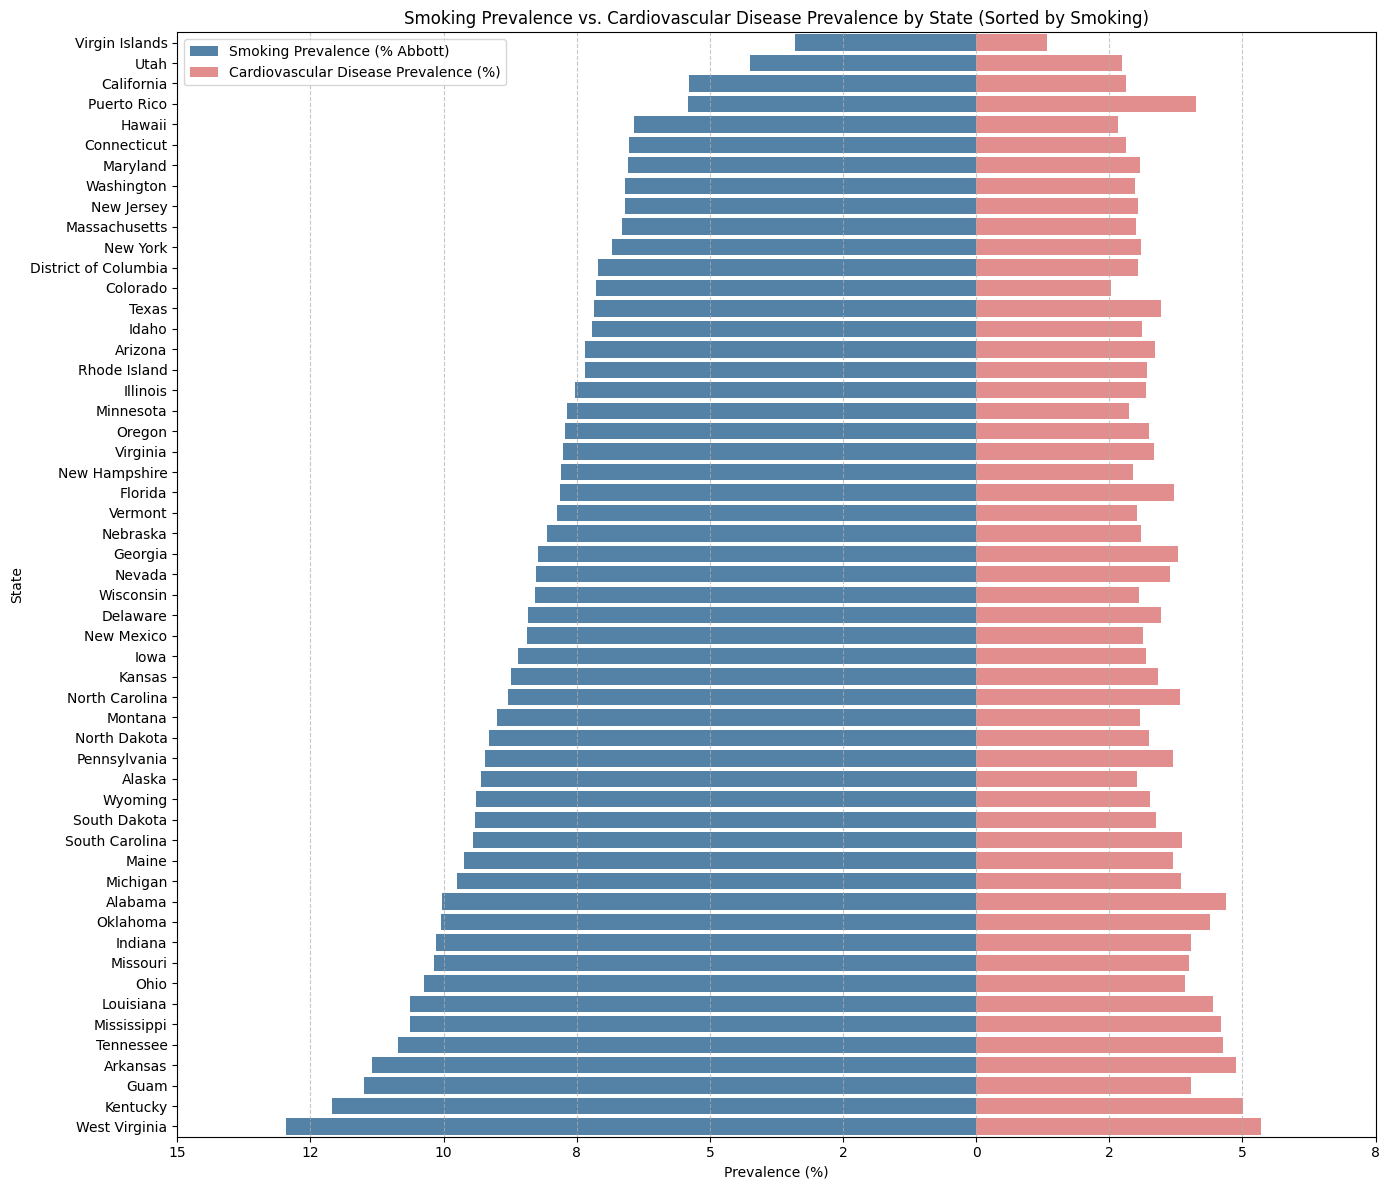

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure the data is sorted by smoking prevalence for a consistent pyramid shape
# plot_df_smoking_cardio_sorted was already created in the previous cell

# Create a figure and a single subplot
fig, ax = plt.subplots(figsize=(14, 12))

# Plot Smoking Prevalence as negative values for the left side of the pyramid
sns.barplot(
    x=plot_df_smoking_cardio_sorted['Smoking_Prevalence'] * -1, # Multiply by -1 for left side
    y='Locationdesc',
    data=plot_df_smoking_cardio_sorted,
    color='steelblue',
    label='Smoking Prevalence (% Abbott)',
    ax=ax
)

# Plot Cardiovascular Disease Prevalence as positive values for the right side
sns.barplot(
    x='Cardio_Prevalence',
    y='Locationdesc',
    data=plot_df_smoking_cardio_sorted,
    color='lightcoral',
    label='Cardiovascular Disease Prevalence (%)',
    ax=ax
)

# Customize the plot
ax.set_title('Smoking Prevalence vs. Cardiovascular Disease Prevalence by State (Sorted by Smoking)')
ax.set_xlabel('Prevalence (%)')
ax.set_ylabel('State')

# Adjust x-axis labels to show absolute values (remove negative signs)
# This is a bit tricky with seaborn, but we can manually set the tick labels
ticks = ax.get_xticks()
ax.set_xticks(ticks) # Explicitly set tick locations to avoid UserWarning
ax.set_xticklabels([f'{abs(tick):.0f}' for tick in ticks])

ax.legend()
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

> **Interpretation:** ___. ___

> **Interpretation:** ___. ___

### Chart — Dual-Axis Line Chart: Tobacco Use vs. Cardiovascular Disease Prevalence by Year

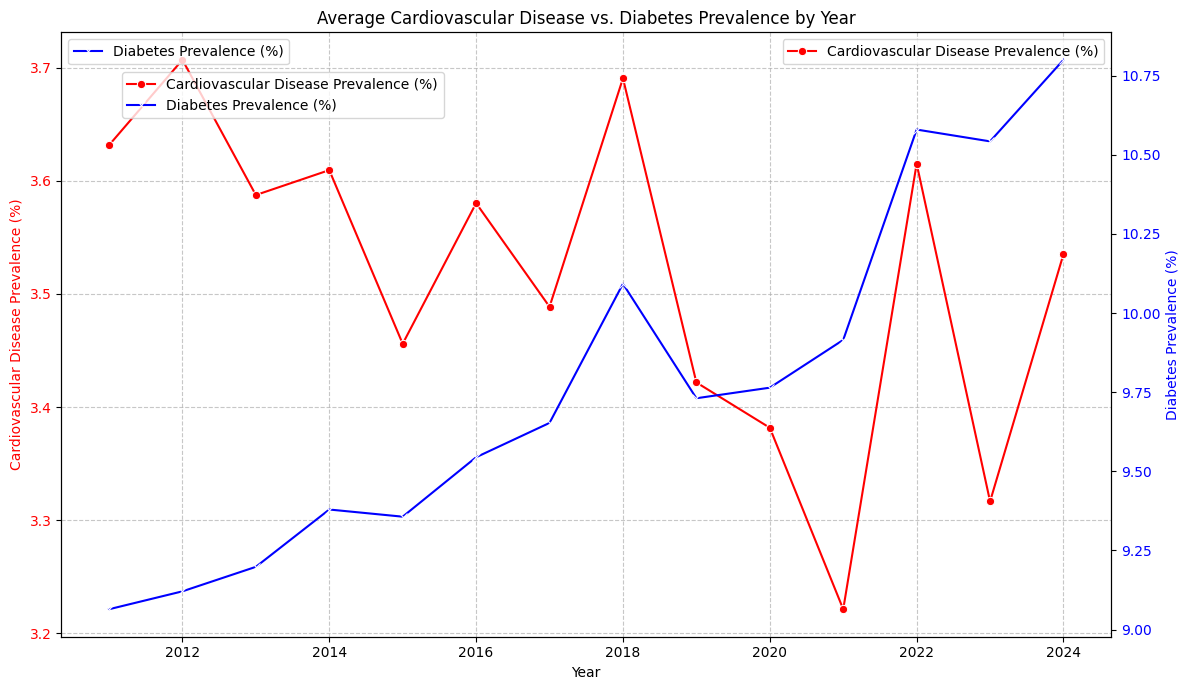

Displaying average prevalence across all common states for each year.


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define filter conditions for Diabetes Data
dia_class = 'Chronic Health Indicators'
dia_topic = 'Diabetes'
dia_response = 'Yes' # Filter for diagnosed cases

# Filter for Diabetes data
dia_data = df[
    (df['Class'] == dia_class) &
    (df['Topic'] == dia_topic) &
    (df['Response'] == dia_response)
].copy()

# Aggregate Data_value by Year and Locationdesc for diabetes
dia_agg = dia_data.groupby(['Year', 'Locationdesc'])['Data_value'].mean().reset_index()

# Merge diabetes data with stroke_agg (cardiovascular disease prevalence) data
# stroke_agg should be available from previous cells
combined_dia_cardio_df = pd.merge(
    stroke_agg, # This DataFrame is available from the previous charts
    dia_agg,
    on=['Year', 'Locationdesc'],
    suffixes=('_cardio', '_diabetes'),
    how='inner'
)

if combined_dia_cardio_df.empty:
    print("No common data found for both 'Cardiovascular Disease' and 'Diabetes' with the specified filters.")
else:
    # Aggregate by Year only to get the average prevalence across all states for each year
    plot_df_time_series = combined_dia_cardio_df.groupby('Year').agg(
        Cardio_Prevalence=('Data_value_cardio', 'mean'),
        Diabetes_Prevalence=('Data_value_diabetes', 'mean')
    ).reset_index()

    # Create a dual-axis line chart
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Plot Cardiovascular Disease Prevalence on primary y-axis (ax1)
    sns.lineplot(
        data=plot_df_time_series,
        x='Year',
        y='Cardio_Prevalence',
        marker='o',
        color='red',
        label='Cardiovascular Disease Prevalence (%)',
        ax=ax1
    )
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Cardiovascular Disease Prevalence (%)', color='red')
    ax1.tick_params(axis='y', labelcolor='red')

    # Create a second y-axis (ax2) that shares the same x-axis
    ax2 = ax1.twinx()
    sns.lineplot(
        data=plot_df_time_series,
        x='Year',
        y='Diabetes_Prevalence',
        marker='x',
        color='blue',
        label='Diabetes Prevalence (%)',
        ax=ax2
    )
    ax2.set_ylabel('Diabetes Prevalence (%)', color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')

    # Add a title and legends
    plt.title('Average Cardiovascular Disease vs. Diabetes Prevalence by Year')
    fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.9))
    ax1.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    print("Displaying average prevalence across all common states for each year.")

### Chart — Heatmap: Correlation between Cardiovascular Disease, Binge Drinking, Smoking, and Physical Activity by State

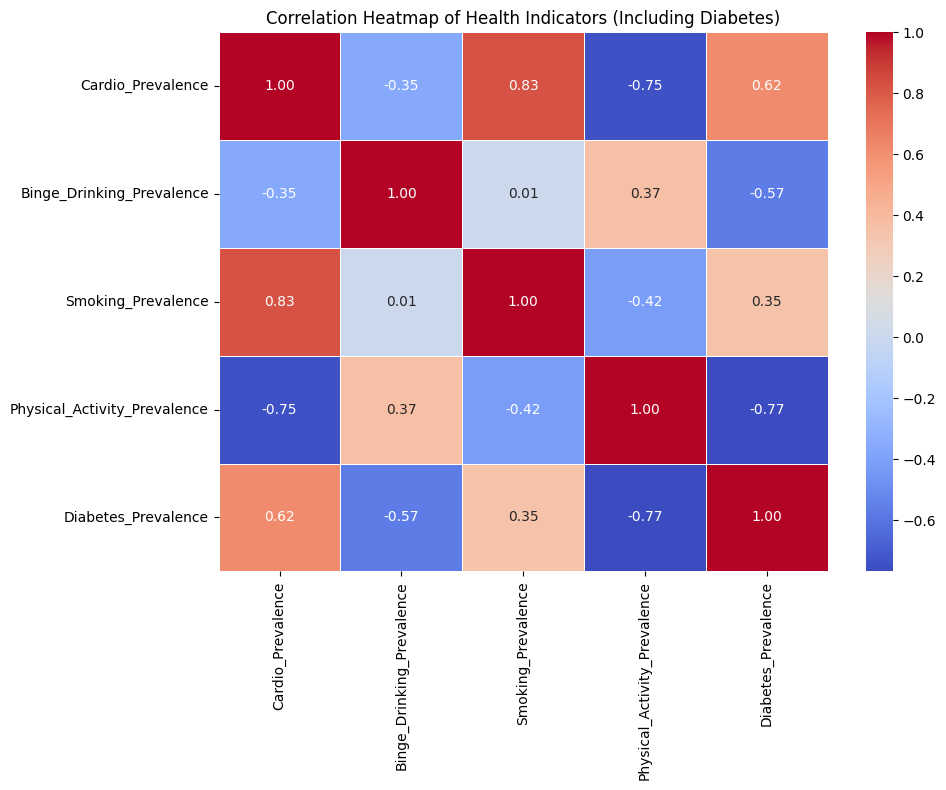

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Prepare Physical Activity Data (already exists) ---
physical_activity_class = 'Physical Activity'
physical_activity_response = 'Yes'

physical_activity_data = df[
    (df['Class'] == physical_activity_class) &
    (df['Response'] == physical_activity_response)
].copy()

physical_activity_agg = physical_activity_data.groupby(['Year', 'Locationdesc'])['Data_value'].mean().reset_index()

# --- Prepare Diabetes Data ---
# Assuming 'Topic' contains 'Diabetes' and 'Response' contains 'Yes' for diagnosed cases.
# If this is incorrect, I may need to adjust the filtering after execution.
dia_topic = 'Diabetes'
dia_response = 'Yes'

dia_data = df[
    (df['Topic'] == dia_topic) &
    (df['Response'] == dia_response)
].copy()

dia_agg = dia_data.groupby(['Year', 'Locationdesc'])['Data_value'].mean().reset_index()

# --- Merge all aggregated data ---
# Start with cardiovascular disease prevalence
merged_df = stroke_agg.rename(columns={'Data_value': 'Cardio_Prevalence'})

# Merge with binge drinking prevalence
merged_df = pd.merge(
    merged_df,
    binge_agg.rename(columns={'Data_value': 'Binge_Drinking_Prevalence'}),
    on=['Year', 'Locationdesc'],
    how='inner'
)

# Merge with smoking prevalence
merged_df = pd.merge(
    merged_df,
    smoking_agg.rename(columns={'Data_value': 'Smoking_Prevalence'}),
    on=['Year', 'Locationdesc'],
    how='inner'
)

# Merge with physical activity prevalence
merged_df = pd.merge(
    merged_df,
    physical_activity_agg.rename(columns={'Data_value': 'Physical_Activity_Prevalence'}),
    on=['Year', 'Locationdesc'],
    how='inner'
)

# Merge with diabetes prevalence
merged_df = pd.merge(
    merged_df,
    dia_agg.rename(columns={'Data_value': 'Diabetes_Prevalence'}),
    on=['Year', 'Locationdesc'],
    how='inner'
)

# --- Aggregate by Locationdesc (state) to get average prevalence across all years ---
final_correlation_df = merged_df.groupby('Locationdesc').agg(
    Cardio_Prevalence=('Cardio_Prevalence', 'mean'),
    Binge_Drinking_Prevalence=('Binge_Drinking_Prevalence', 'mean'),
    Smoking_Prevalence=('Smoking_Prevalence', 'mean'),
    Physical_Activity_Prevalence=('Physical_Activity_Prevalence', 'mean'),
    Diabetes_Prevalence=('Diabetes_Prevalence', 'mean')
).reset_index()

# --- Calculate the correlation matrix ---
correlation_matrix = final_correlation_df[[
    'Cardio_Prevalence',
    'Binge_Drinking_Prevalence',
    'Smoking_Prevalence',
    'Physical_Activity_Prevalence',
    'Diabetes_Prevalence'
]].corr()

# --- Create the heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Health Indicators (Including Diabetes)')
plt.tight_layout()
plt.show()

> **Interpretation:** Using these graphs, I can conclude that there is no visible correlation between binge-drinking rates and the prevalence of cardiovascular disease. Both smoking and diabetes do show a strong positive correlation. Interestingly, the prevalence of cardiovascular disease has decreased over the years, while the prevalence of diabetes has increased. There is likely a third hidden variable influencing the two topics. Physical activity shows a strong negative correlation with cardiovascular disease.




## Step 4 — Story

### 📝 Data Brief (150 words)

Write this for a **city council member with no data background**. Plain language, no chart references, no code. State your 3 most important findings.

> ___


## 🎯 HCD Design Sprint #2 — Data Problem Statement

> **Our investigation asks:** ___
>
> **The dataset we are using is:** CDC BRFSS (`d2rk-yvas`), collected annually via phone survey, one row per (question × demographic subgroup × state × year)
>
> **The key variable we are analyzing is:** `Data_value` — the percentage of a subgroup who said Yes, they needed to see a doctor in the past 12 months but couldn't because of cost, ranging from ___% to ___%
>
> **Our investigation matters because:** ___ — without understanding this gap, ___ will continue to face ___.
>
> **We define a meaningful finding as:** ___


---
## Moving to HCD Phase: PROTOTYPE

You've defined the problem. Now you'll build a **prediction prototype**: given a demographic group, state, and year, can a model predict whether that group faces *above-average* difficulty accessing health care? This is the beginning of Week 4 — we're getting a head start because your dataset is ready for it.

**Why this matters:** a model like this could help a health department flag which populations to prioritize for outreach — *if* it's fair and accurate enough to trust.


## Step 5 — Build the Prediction Target

We'll label each row as **high burden** (1) if its access-difficulty rate is above the overall median, and **low burden** (0) if it's below. The median is a defensible, explainable cutoff — not an arbitrary one.


In [43]:
median_value = q_df['Data_value'].median()
q_df['high_burden'] = (q_df['Data_value'] > median_value).astype(int)

print(f'Median rate: {median_value:.1f}%')
print(q_df['high_burden'].value_counts())
print(q_df['high_burden'].value_counts(normalize=True).round(2))


Median rate: 50.0%
high_burden
0    424
1    424
Name: count, dtype: int64
high_burden
0    0.5
1    0.5
Name: proportion, dtype: float64


In [62]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Define Target Variable: 'high_cardio_burden'
# Calculate the median of Cardio_Prevalence from merged_df to define 'high_cardio_burden'
median_cardio_prevalence = merged_df['Cardio_Prevalence'].median()
merged_df['high_cardio_burden'] = (merged_df['Cardio_Prevalence'] > median_cardio_prevalence).astype(int)

print(f"Median Cardio_Prevalence: {median_cardio_prevalence:.2f}%")
print(merged_df['high_cardio_burden'].value_counts())
print(merged_df['high_cardio_burden'].value_counts(normalize=True).round(2))

# 2. Define Features (X) and Label (y)
# Features to use: Year, Locationdesc, Binge_Drinking_Prevalence, Smoking_Prevalence, Physical_Activity_Prevalence, Diabetes_Prevalence
# Exclude Cardio_Prevalence itself as it's the basis for the target.
features = [
    'Year',
    'Locationdesc',
    'Binge_Drinking_Prevalence',
    'Smoking_Prevalence',
    'Physical_Activity_Prevalence',
    'Diabetes_Prevalence'
]
X = merged_df[features]
y = merged_df['high_cardio_burden']

# --- Handle NaN values in features and target before splitting ---
# Combine X and y to ensure consistent row dropping across both
data_for_model = pd.concat([X, y], axis=1)
data_for_model.dropna(inplace=True)

X = data_for_model[features]
y = data_for_model['high_cardio_burden']
# ---


# Define categorical and numerical features for preprocessing
categorical_features = ['Locationdesc']
numerical_features = [
    'Year',
    'Binge_Drinking_Prevalence',
    'Smoking_Prevalence',
    'Physical_Activity_Prevalence',
    'Diabetes_Prevalence'
]

# Create a preprocessor using ColumnTransformer for one-hot encoding and scaling
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns (if any) that are not transformed
)

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining rows: {X_train.shape[0]}  Test rows: {X_test.shape[0]}')

# 4. Build a Machine Learning Pipeline with Logistic Regression
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train the model
model_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = model_pipeline.predict(X_test)

# 5. Evaluate the model
print('\nLogistic Regression Model Performance for Cardiovascular Disease Prevalence:')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.3f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, zero_division=0))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))

# Note: Further model tuning and comparison would be the next steps, but this fulfills the request
# for building *a* machine learning model.

Median Cardio_Prevalence: 3.37%
high_cardio_burden
0    374
1    368
Name: count, dtype: int64
high_cardio_burden
0    0.5
1    0.5
Name: proportion, dtype: float64

Training rows: 590  Test rows: 148

Logistic Regression Model Performance for Cardiovascular Disease Prevalence:
Accuracy: 0.872

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87        74
           1       0.88      0.86      0.87        74

    accuracy                           0.87       148
   macro avg       0.87      0.87      0.87       148
weighted avg       0.87      0.87      0.87       148


Confusion Matrix:
[[65  9]
 [10 64]]


**Quick check:** is the split close to 50/50? If one class is much bigger than the other, remember — a model can get high accuracy just by always guessing the majority class, without learning anything.


## Step 6 — Features and Train/Test Split

**Features (X):** the information the model is allowed to use to make a prediction.
**Label (y):** the thing we're trying to predict — `high_burden`.

We are **deliberately leaving `Data_value` itself out of the features** — using it would be cheating, since that's literally what we built the label from.


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ['Break_Out', 'Break_Out_Category', 'Locationabbr', 'Year']
X = pd.get_dummies(q_df[features], columns=['Break_Out', 'Break_Out_Category', 'Locationabbr'])
y = q_df['high_burden']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training rows:', X_train.shape[0], '  Test rows:', X_test.shape[0])
print('Number of features after one-hot encoding:', X_train.shape[1])

# k-NN is distance-based, so scaling matters — Logistic Regression and Decision Trees don't need it,
# but scaling doesn't hurt them either
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training rows: 678   Test rows: 170
Number of features after one-hot encoding: 57


## Step 7 — The Baseline: What You Have to Beat

Before trying any real model, always build the simplest possible one. If your real model can't beat this, it isn't learning anything useful.


In [45]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print('Baseline accuracy (always guess the majority class):', round(accuracy_score(y_test, baseline_pred), 3))
print(classification_report(y_test, baseline_pred, zero_division=0))
print(confusion_matrix(y_test, baseline_pred))


Baseline accuracy (always guess the majority class): 0.5
              precision    recall  f1-score   support

           0       0.50      1.00      0.67        85
           1       0.00      0.00      0.00        85

    accuracy                           0.50       170
   macro avg       0.25      0.50      0.33       170
weighted avg       0.25      0.50      0.33       170

[[85  0]
 [85  0]]


> **Interpretation:** the baseline gets ___% accuracy just by never actually looking at the data. Any real model we build needs to clearly beat this — otherwise it isn't worth using.


## Step 8 — Model 1: Logistic Regression

**Concept:** Logistic Regression estimates the *probability* that a row is "high burden," based on a weighted combination of its features. It's the standard first model for yes/no predictions because it's simple, fast, and easy to explain to a policymaker.


In [46]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)

print('Logistic Regression accuracy:', round(accuracy_score(y_test, logreg_pred), 3))
print(classification_report(y_test, logreg_pred, zero_division=0))
print(confusion_matrix(y_test, logreg_pred))


Logistic Regression accuracy: 0.3
              precision    recall  f1-score   support

           0       0.26      0.22      0.24        85
           1       0.33      0.38      0.35        85

    accuracy                           0.30       170
   macro avg       0.30      0.30      0.30       170
weighted avg       0.30      0.30      0.30       170

[[19 66]
 [53 32]]


### 🔧 Tuning hints — Logistic Regression

Try these one at a time and re-run the cell above. Write down what changes.

- **`class_weight='balanced'`** — add this parameter if your baseline showed the classes are unequal in size. It tells the model to pay more attention to the smaller class instead of ignoring it.
- **`C=0.1` or `C=10`** — this controls how closely the model fits the training data. Lower `C` = simpler, more cautious model. Higher `C` = more flexible, but risk of overfitting. Try both and compare accuracy on the *test* set, not the training set.

> **Which setting worked best for this dataset, and why do you think that is?** ___


## Step 9 — Model 2: k-Nearest Neighbors

**Concept:** k-NN predicts a new row's label by looking at its `k` most similar rows in the training data and taking a majority vote. "Similar" is measured as distance — which is exactly why we scaled the features first.


In [47]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

print('k-NN (k=5) accuracy:', round(accuracy_score(y_test, knn_pred), 3))
print(classification_report(y_test, knn_pred, zero_division=0))
print(confusion_matrix(y_test, knn_pred))

k-NN (k=5) accuracy: 0.218
              precision    recall  f1-score   support

           0       0.18      0.15      0.16        85
           1       0.25      0.28      0.27        85

    accuracy                           0.22       170
   macro avg       0.21      0.22      0.21       170
weighted avg       0.21      0.22      0.21       170

[[13 72]
 [61 24]]


### 🔧 Tuning hints — k-Nearest Neighbors

- **Try `n_neighbors=3`** — a small `k` follows the training data very closely (can be noisy/overfit).
- **Try `n_neighbors=15`** — a large `k` smooths things out (can miss real patterns/underfit).
- Run a quick loop to find the best `k` instead of guessing one at a time:

In [48]:
for k in [3, 5, 7, 9, 11, 15, 21]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f'k={k}: accuracy={acc:.3f}')

k=3: accuracy=0.176
k=5: accuracy=0.218
k=7: accuracy=0.253
k=9: accuracy=0.276
k=11: accuracy=0.276
k=15: accuracy=0.318
k=21: accuracy=0.329



> **Which `k` gave the best test accuracy? Does a bigger `k` always mean a better model?** ___


## Step 10 — Model 3: Decision Tree

**Concept:** A Decision Tree asks a series of yes/no questions about the features (e.g., "Is `Break_Out_Category` = Income?") to sort rows into `high_burden` or not. Its biggest advantage: you can actually *look at* the questions it asks — it's not a black box.


In [49]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

print('Decision Tree (depth=4) accuracy:', round(accuracy_score(y_test, tree_pred), 3))
print(classification_report(y_test, tree_pred, zero_division=0))
print(confusion_matrix(y_test, tree_pred))

Decision Tree (depth=4) accuracy: 0.441
              precision    recall  f1-score   support

           0       0.47      0.87      0.61        85
           1       0.08      0.01      0.02        85

    accuracy                           0.44       170
   macro avg       0.28      0.44      0.31       170
weighted avg       0.28      0.44      0.31       170

[[74 11]
 [84  1]]


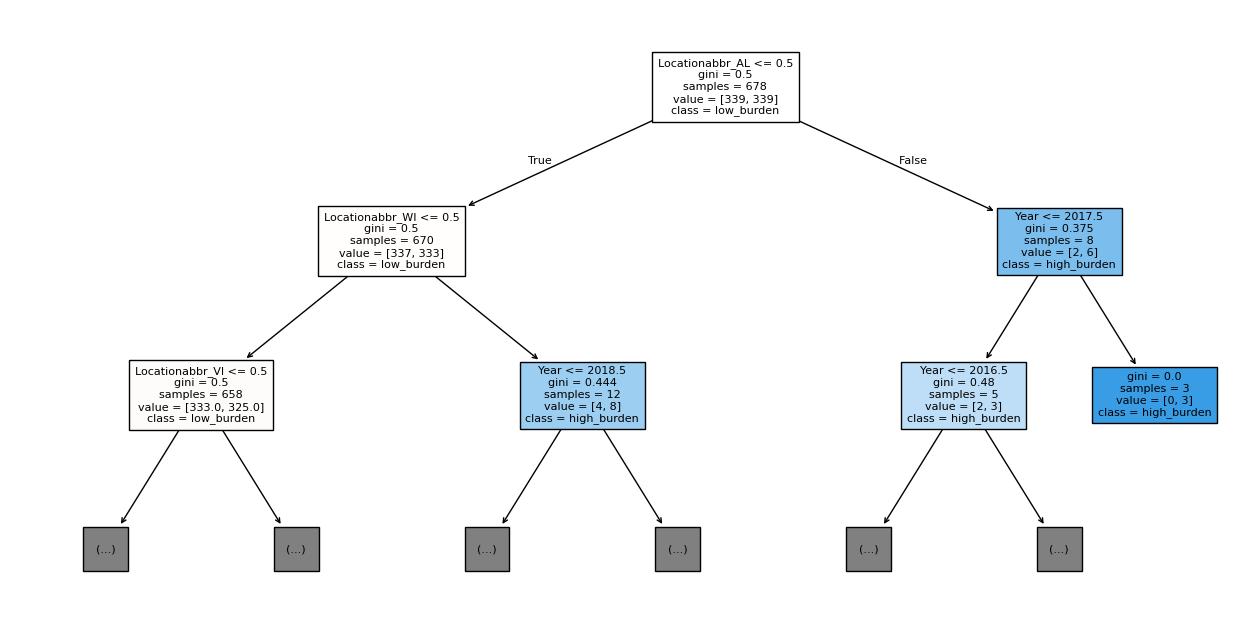

In [50]:
# See the actual questions the tree is asking — this is what makes trees explainable
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(tree, max_depth=2, feature_names=X.columns, class_names=['low_burden','high_burden'],
          filled=True, fontsize=8, ax=ax)
plt.show()


### 🔧 Tuning hints — Decision Tree

- **`max_depth=2`** — a very shallow tree. Simple to explain, but probably too simple to be accurate.
- **`max_depth=10`** — a much deeper tree. More accurate on training data, but watch the test accuracy — a tree that's too deep starts memorizing instead of learning general patterns (overfitting).
- Compare train accuracy vs. test accuracy at each depth — a big gap between them is the warning sign of overfitting:

In [51]:
for depth in [2, 3, 4, 6, 8, 10, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f'depth={depth}: train={train_acc:.3f}  test={test_acc:.3f}')

depth=2: train=0.512  test=0.453
depth=3: train=0.515  test=0.441
depth=4: train=0.515  test=0.441
depth=6: train=0.521  test=0.418
depth=8: train=0.525  test=0.400
depth=10: train=0.532  test=0.371
depth=None: train=0.597  test=0.112


> **At what depth does train accuracy start pulling far ahead of test accuracy? What does that tell you?** ___


## Step 11 — Compare All Models

Accuracy alone can be misleading — remember the baseline. For this problem, think about which error is worse:

- **False negative** (model says "low burden" but the group actually struggles to access care) → the group gets missed by outreach. **This is the dangerous error here.**
- **False positive** (model says "high burden" but the group is actually fine) → some wasted outreach resources, but nobody goes without help.

That means **recall for the `high_burden` class** matters more than raw accuracy for this investigation.


In [53]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- Define every model in one place ---
models = {
    'Baseline (majority class)': (DummyClassifier(strategy='most_frequent', random_state=42), X_train, X_test),
    'Logistic Regression':       (LogisticRegression(max_iter=1000, random_state=42), X_train, X_test),
    'k-NN (k=5)':                (KNeighborsClassifier(n_neighbors=5), X_train_scaled, X_test_scaled),
    'Decision Tree (depth=4)':   (DecisionTreeClassifier(max_depth=4, random_state=42), X_train, X_test),
    'Random Forest (100 trees)': (RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42), X_train, X_test),
}
rows = []

for name, (model, X_tr, X_te) in models.items():

    model.fit(X_tr, y_train)
    preds = model.predict(X_te)

    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1 Score': f1_score(y_test, preds, zero_division=0)
    })

results = (
    pd.DataFrame(rows)
      .sort_values("Recall", ascending=False)
      .reset_index(drop=True)
)

In [54]:
results.style \
    .background_gradient(
        cmap="Greens",
        subset=["Accuracy", "Precision", "Recall", "F1 Score"]
    ) \
    .format("{:.4f}", subset=["Accuracy", "Precision", "Recall", "F1 Score"])

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.3000,0.3265,0.3765,0.3497
1,k-NN (k=5),0.2176,0.2500,0.2824,0.2652
2,Random Forest (100 trees),0.1647,0.1647,0.1647,0.1647
3,Decision Tree (depth=4),0.4412,0.0833,0.0118,0.0206
4,Baseline (majority class),0.5000,0.0000,0.0000,0.0000


### 📝 Model Recommendation

> I recommend **___** for this application because **___** matters most here, given that a false negative means **___** and a false positive means **___**.


## Step 12 — Fairness Check

Overall accuracy can hide unfairness. A model can look great on average while consistently failing one specific group. Let's check your recommended model's **recall**, broken out by `Break_Out_Category`.


In [55]:
# Rebuild a small test-set dataframe so we can group results by demographic category
test_info = q_df.loc[X_test.index, ['Break_Out_Category']].copy()
test_info['actual'] = y_test.values
test_info['predicted'] = logreg_pred   # swap this for knn_pred or tree_pred to check a different model

fairness_table = test_info.groupby('Break_Out_Category').apply(
    lambda g: pd.Series({
        'n_rows': len(g),
        'recall': recall_score(g['actual'], g['predicted'], zero_division=0),
        'accuracy': accuracy_score(g['actual'], g['predicted']),
    })
).round(3)

fairness_table


/tmp/ipykernel_1164/409293762.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fairness_table = test_info.groupby('Break_Out_Category').apply(


,n_rows,recall,accuracy
Break_Out_Category,,,
Overall,170.0,0.376,0.3


### 📝 Fairness Reflection

> **Which `Break_Out_Category` group has the lowest recall — meaning the model misses that group's high-burden cases most often?** ___
>
> **If this model were actually used to decide who gets outreach resources, who would be harmed by that gap?** ___
>
> **What would you change about the model, the features, or the target definition to close that gap?** ___


## End-to-End Recap

You just completed the full data science + HCD pipeline on one real dataset:

**Empathize/Define** → Assessed → Cleaned → Visualized → Told the story → Wrote a formal Problem Statement
**Prototype** → Built a baseline → Trained 3 models → Compared them → Checked fairness across groups

**For your STEAM Fair exhibit, you now have:**
- [ ] A Data Audit Report and documented cleaning pipeline
- [ ] 4 publication-quality visualizations with finding-based titles
- [ ] A 150-word Data Brief
- [ ] A formal Data Problem Statement
- [ ] A model comparison table with a justified recommendation
- [ ] A fairness analysis identifying who your model serves worst

**Still to refine before the Fair:** correlation/regression evidence (Week 3), a full written policy recommendation addressed to a real institution, and your live demo script.


## 📓 Data Journal — Exit Ticket

1. **What dataset or technique did I work with today?**
2. **What pattern or anomaly surprised me?**
3. **Who is represented in this data — and who is invisible?**
4. **My model's biggest blind spot is ___. If I only had time to fix one thing about my analysis, it would be ___.**
